# DermaMNIST CNN Baseline

This notebook establishes a single-process CNN baseline using the **DermaMNIST 64×64** dataset.

The **non-distributed baseline** baseline will later be used for comparison with distributed CNN training.

The baseline will establish:

1. CNN architecture and hyperparameters
2. Training and validation procedure
3. Classification performance
4. Training time
5. Resource usage where practical

### Dataset

DermaMNIST is part of the **MedMNIST+** collection and is derived from the **HAM10000** dataset of dermatoscopic images of pigmented skin lesions. Official destribution link: https://zenodo.org/records/10519652

* **Task:** multiclass image classification
* **Number of classes:** 7
* **Total images:** 10,015
* **Image type:** RGB dermatoscopic images
* **Image resolution:** 64 × 64 pixels
* **Training images:** 7,007
* **Validation images:** 1,003
* **Test images:** 2,005

The 64×64 version is selected because it provides a substantially more realistic image-classification workload than MNIST while remaining within the project's recommended dataset size of less than approximately 200 MB.

#### Dataset License: 

DermaMNIST is distributed under the *Creative Commons Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)* license.

This permits use, sharing and adaptation subject to the license conditions, including:

- Attribution: appropriate credit must be given to the dataset creators and source.
- Non-commercial use: the dataset may not be used for commercial purposes.
- License notice: the applicable license and any relevant changes must be indicated when redistributing or adapting the material.

The dataset is used here for academic research and educational purposes.

### Install MedMNIST

In [2]:
# pip install medmnist

In [62]:
import medmnist
from medmnist import DermaMNIST

import os
import time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader

from sklearn.metrics import classification_report, confusion_matrix, f1_score

print("MedMNIST version:", medmnist.__version__)

MedMNIST version: 3.0.2


### Download DermaMNIST 64×64

In [4]:
train_dataset = DermaMNIST(split="train", size=64, download=True)
val_dataset = DermaMNIST(split="val", size=64, download=True)
test_dataset = DermaMNIST(split="test", size=64, download=True)

100%|████████████████████████████████████████████████████████████████████████████| 100M/100M [00:17<00:00, 5.87MB/s]


In [5]:
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 7007
Validation: 1003
Test: 2005


In [7]:
# Inspect the dataset structure

print("Dataset type:", type(train_dataset))
print("Number of samples:", len(train_dataset))

image, label = train_dataset[0]

print("Image type:", type(image))
print("Image size:", image.size)
print("Image mode:", image.mode)
print("Label:", label)
print("Label type:", type(label))

Dataset type: <class 'medmnist.dataset.DermaMNIST'>
Number of samples: 7007
Image type: <class 'PIL.Image.Image'>
Image size: (64, 64)
Image mode: RGB
Label: [0]
Label type: <class 'numpy.ndarray'>


In [14]:
# where the physical dataset file is located
print("Root:", train_dataset.root)
print("Dataset root contents:", os.listdir(train_dataset.root))
print("Current working directory:", os.getcwd())

Root: /home/hduser/.medmnist
Dataset root contents: ['dermamnist_64.npz']
Current working directory: /home/hduser/Desktop/CA1


In [16]:
# check the actual .npz file
dataset_file = Path(train_dataset.root) / "dermamnist_64.npz"

file_size_mb = dataset_file.stat().st_size / (1024 ** 2)

print("Dataset file:", dataset_file)
print(f"File size: {file_size_mb:.2f} MB")

Dataset file: /home/hduser/.medmnist/dermamnist_64.npz
File size: 95.49 MB


In [17]:
# inspect what's inside the archive without extracting it
with np.load(dataset_file) as data:
    print("Files in archive:")
    for key in data.files:
        print(f"  {key}: {data[key].shape}, {data[key].dtype}")

Files in archive:
  train_images: (7007, 64, 64, 3), uint8
  train_labels: (7007, 1), uint8
  val_images: (1003, 64, 64, 3), uint8
  val_labels: (1003, 1), uint8
  test_images: (2005, 64, 64, 3), uint8
  test_labels: (2005, 1), uint8


Images are stored as unsigned 8-bit integer (uint8) RGB arrays.

The dataset remains in its compressed `.npz` format rather than being extracted into individual image files. This avoids creating thousands of small files and provides a compact source that can later be transfered to distributed storage.

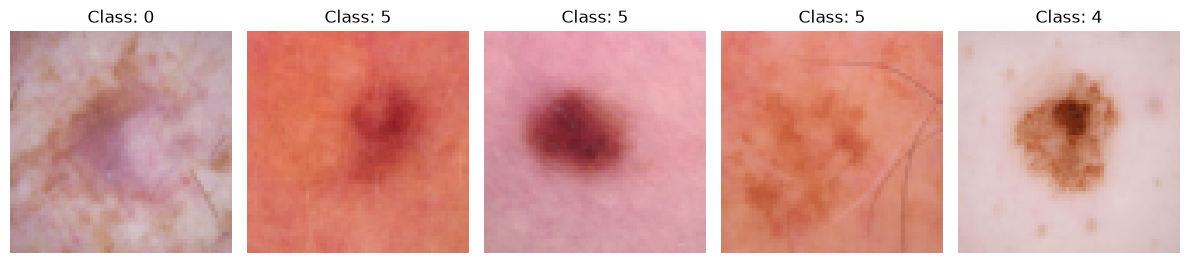

In [21]:
# let's actually look at some images
fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for i in range(5):
    image, label = train_dataset[i]
    
    axes[i].imshow(image)
    axes[i].set_title(f"Class: {label[0]}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [23]:
# MedMNIST provides the class information through the dataset metadata 
# let's inspect the class labels
print("Number of classes:", len(train_dataset.info["label"]))
print("\nClass labels:")

for key, name in train_dataset.info["label"].items():
    print(f"{key}: {name}")

Number of classes: 7

Class labels:
0: actinic keratoses and intraepithelial carcinoma
1: basal cell carcinoma
2: benign keratosis-like lesions
3: dermatofibroma
4: melanoma
5: melanocytic nevi
6: vascular lesions


In [28]:
# let's also count the training examples in each class to see if there's any significant class imbalance
train_labels = train_dataset.labels.flatten()

class_counts = Counter(train_labels)

print("Training class distribution:\n")

for class_id in sorted(class_counts):
    count = class_counts[class_id]
    percentage = count / len(train_labels) * 100
    
    print(f"{class_id}: {count:4d} ({percentage:5.2f}%)")

Training class distribution:

0:  228 ( 3.25%)
1:  359 ( 5.12%)
2:  769 (10.97%)
3:   80 ( 1.14%)
4:  779 (11.12%)
5: 4693 (66.98%)
6:   99 ( 1.41%)


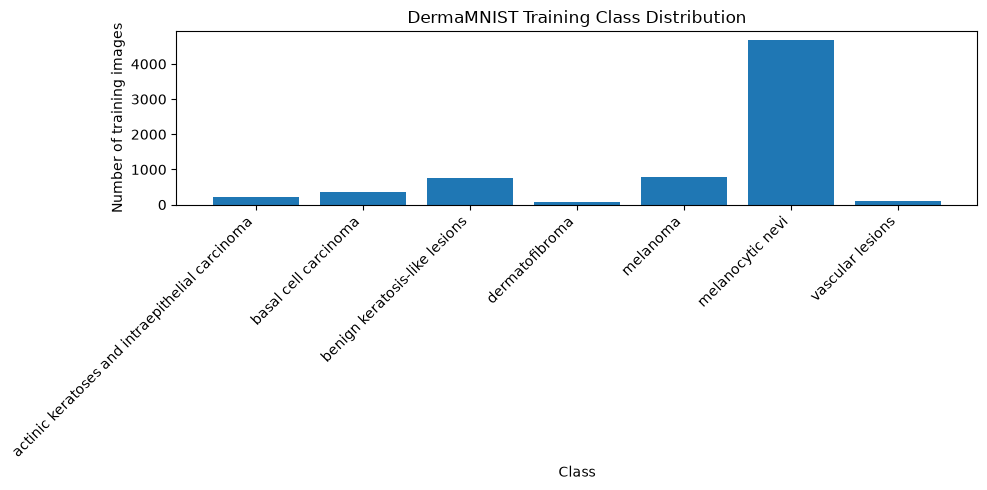

In [32]:
# visualise the imbalance
class_names = [train_dataset.info["label"][str(i)] for i in range(7)]
counts = [class_counts[i] for i in range(7)]

plt.figure(figsize=(10, 5))
plt.bar(range(7), counts)

plt.xticks(range(7), class_names, rotation=45, ha="right")

plt.ylabel("Number of training images")
plt.xlabel("Class")
plt.title("DermaMNIST Training Class Distribution")

plt.tight_layout()
plt.show()

The dataset is highly imbalanced, with melanocytic nevi (Class 5) making up ~67% of the training set, while dermatofibroma (Class 3) and vascular lesions (Class 6) each account for only 1–1.5%.

Because of this imbalance, classification accuracy alone may provide an incomplete assessment of model performance. In addition to accuracy, the experiment will consider class-sensitive metrics such as calculating macro-F1 score for each of the 7 classes and taking the unweighted mean of those seven F1 scores. We're interested in whether the CNN can learn the multiclass problem as a whole, rather than simply optimise performance on the most common nevi class.

### Image Preprocessing

The raw DermaMNIST images are stored as 64×64 RGB `uint8` images.

For CNN training, the images will be converted to PyTorch tensors and normalised.


In [34]:
train_images = train_dataset.imgs

print("Shape:", train_images.shape)
print("dtype:", train_images.dtype)
print("Pixel range:", train_images.min(), "to", train_images.max())

Shape: (7007, 64, 64, 3)
dtype: uint8
Pixel range: 0 to 255


In [35]:
# calculate the per-channel mean and standard deviation
train_images_float = train_images.astype(np.float32) / 255.0

mean = train_images_float.mean(axis=(0, 1, 2))
std = train_images_float.std(axis=(0, 1, 2))

print("Mean:", mean)
print("Std:", std)

Mean: [0.5845583  0.58314306 0.5845583 ]
Std: [0.21778087 0.15745011 0.16998562]


In [36]:
# use calculated values to standardise the input images before CNN training
transform = transforms.Compose([
    transforms.ToTensor(),   # 3 × 64 × 64
    # ToTensor() scales input image to [0.0, 1.0]
    transforms.Normalize(mean=mean.tolist(), std=std.tolist())
])

In [37]:
# apply transform
train_dataset_tensor = DermaMNIST(split="train", size=64, transform=transform, download=False)
val_dataset_tensor = DermaMNIST(split="val", size=64, transform=transform, download=False)
test_dataset_tensor = DermaMNIST(split="test", size=64, transform=transform, download=False)

In [39]:
# inspect the result
image, label = train_dataset_tensor[0]

print("Image type:", type(image))
print("Image shape:", image.shape)
print("Image dtype:", image.dtype)
print("Label:", label)
print("Label type:", type(label))
print("Pixel minimum:", image.min().item())
print("Pixel maximum:", image.max().item())

Image type: <class 'torch.Tensor'>
Image shape: torch.Size([3, 64, 64])
Image dtype: torch.float32
Label: [0]
Label type: <class 'numpy.ndarray'>
Pixel minimum: -1.6163389682769775
Pixel maximum: 1.198201298713684


### DataLoaders

PyTorch `DataLoaders` are used to provide mini-batches of images to the CNN during training and evaluation. https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html

The training DataLoader uses shuffling so that the order of training samples changes between epochs. Validation and test data are not shuffled because their ordering does not affect evaluation.

A batch size of **64** is used as the initial baseline configuration. This provides a reasonable balance between computational efficiency and memory usage on the VM.

The same batch size will initially be used when comparing single-process and distributed training, and will be adjusted if required by the distributed configuration.


In [41]:
batch_size = 64

train_loader = DataLoader(train_dataset_tensor, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset_tensor, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset_tensor, batch_size=batch_size, shuffle=False)

In [42]:
# check one batch
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Images dtype:", images.dtype)
print("Labels shape:", labels.shape)
print("Labels dtype:", labels.dtype)

Images shape: torch.Size([64, 3, 64, 64])
Images dtype: torch.float32
Labels shape: torch.Size([64, 1])
Labels dtype: torch.int64


### CNN Architecture

We start with a small convolutional neural network to use it as the baseline model.

We start with three convolutional blocks followed by two fully connected layers:

1. Convolution 32 filters + Max pooling [2x2]  (out shape= 32x32x32)
3. Convolution 64 filters + Max pooling [2x2]  (out shape= 64x16x16)
5. Convolution 128 filters + Max pooling [2x2] (out shape= 128x8x8)
7. Fully connected layer: 128 × 8 × 8 → 128
8. Dropout
9. Output layer: 128 → 7 classes

ReLU activation is used after each convolution and the first fully connected layer.


In [44]:
class CNN(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        self.features = nn.Sequential(
            # 3 × 64 × 64
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # 32 × 32 × 32
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # 64 × 16 × 16
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            # 128 × 8 × 8
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [45]:
model = CNN(num_classes=7)
print(model)

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=7, bias=True)
  )
)


In [46]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Total parameters: 1,142,855


In [47]:
images, labels = next(iter(train_loader))

outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)

Input shape: torch.Size([64, 3, 64, 64])
Output shape: torch.Size([64, 7])


### Loss function and optimiser

Our problem is 7-class single-label classification, i.e. each image belongs to exactly one class. **Cross-entropy loss** is appropriate here because our CNN outputs 7 values per image, and the target is a single class index.

For optimiser, we'll start with **Adam**.

In [48]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [51]:
# training function
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        # remove the redundant dimension: (64, 1) → (64,)
        labels = labels.squeeze(1)

        optimizer.zero_grad()   # clear gradients from the previous batch

        outputs = model(images)   # perform the forward pass
        loss = criterion(outputs, labels)   # calculate the classification loss
        loss.backward()   # calculate gradients
        optimizer.step()   # update model parameters

        # CrossEntropyLoss() by default returns the average loss for the batch
        # we want the running_loss to represent the sum of the individual sample losses
        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [63]:
# validation function
def evaluate(model, loader, criterion):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_predictions = []
    all_labels = []

    # we're telling PyTorch that this is evaluation rather than training, and that we don't need to calculate gradients
    with torch.no_grad():
        for images, labels in loader:
            labels = labels.squeeze(1)
            
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

            all_predictions.extend(predictions.numpy())
            all_labels.extend(labels.numpy())

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total
    epoch_macro_f1 = f1_score(all_labels, all_predictions, average="macro", zero_division=0)

    return epoch_loss, epoch_accuracy, epoch_macro_f1

### Run the baseline

We initially use 10 epochs.

In [65]:
num_epochs = 10

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_macro_f1": [],
    "epoch_time": []
}

baseline_start = time.perf_counter()

for epoch in range(num_epochs):

    epoch_start = time.perf_counter()

    train_loss, train_accuracy = train_one_epoch(model, train_loader, criterion, optimizer)

    val_loss, val_accuracy, val_macro_f1 = evaluate(model, val_loader, criterion)

    epoch_time = time.perf_counter() - epoch_start

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)
    history["val_macro_f1"].append(val_macro_f1)
    history["epoch_time"].append(epoch_time)

    print(
        f"Epoch {epoch + 1:2d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Val Macro-F1: {val_macro_f1:.4f} | "
        f"Time: {epoch_time:.2f}s")

baseline_time = time.perf_counter() - baseline_start

print(f"\nTotal training time: {baseline_time:.2f}s")

Epoch  1/10 | Train Loss: 0.9858 | Train Acc: 0.6653 | Val Loss: 0.8012 | Val Acc: 0.6830 | Val Macro-F1: 0.1655 | Time: 26.65s
Epoch  2/10 | Train Loss: 0.8423 | Train Acc: 0.6893 | Val Loss: 0.7574 | Val Acc: 0.7099 | Val Macro-F1: 0.2517 | Time: 26.27s
Epoch  3/10 | Train Loss: 0.7900 | Train Acc: 0.7091 | Val Loss: 0.7449 | Val Acc: 0.7268 | Val Macro-F1: 0.3362 | Time: 26.42s
Epoch  4/10 | Train Loss: 0.7575 | Train Acc: 0.7228 | Val Loss: 0.6953 | Val Acc: 0.7527 | Val Macro-F1: 0.3876 | Time: 26.21s
Epoch  5/10 | Train Loss: 0.7416 | Train Acc: 0.7264 | Val Loss: 0.6899 | Val Acc: 0.7308 | Val Macro-F1: 0.3695 | Time: 26.28s
Epoch  6/10 | Train Loss: 0.7012 | Train Acc: 0.7433 | Val Loss: 0.6766 | Val Acc: 0.7498 | Val Macro-F1: 0.4091 | Time: 26.32s
Epoch  7/10 | Train Loss: 0.6852 | Train Acc: 0.7448 | Val Loss: 0.6797 | Val Acc: 0.7468 | Val Macro-F1: 0.3998 | Time: 26.27s
Epoch  8/10 | Train Loss: 0.6408 | Train Acc: 0.7645 | Val Loss: 0.6340 | Val Acc: 0.7667 | Val Macro-F1

What we can see from here:
- Macro-F1 increased from 0.166 to 0.449, so the model is clearly learning minority classes as training progresses
- Validation accuracy peaked at 77.07% at epoch 9
- Validation macro-F1 peaked at 0.4493 at epoch 8
- Validation loss was also lowest at epoch 8, then started increasing
- Training accuracy continued increasing through epoch 10 while validation performance stopped improving, meaning that some overfitting is beginning around epochs 8-10
- Each epoch took remarkably consistently ~26.3 s

In [80]:
# plot learning curves

def plot_learning_curves(history, title=None):
    """Plot training/validation learning curves for a CNN experiment."""

    epochs = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Loss
    axes[0].plot(epochs, history["train_loss"], marker="o", label="Training", color="orange")
    axes[0].plot(epochs, history["val_loss"], marker="o", label="Validation", color="green")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Loss")
    axes[0].set_xticks(list(epochs))
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Accuracy
    axes[1].plot(epochs, history["train_accuracy"], marker="o", label="Training", color="orange")
    axes[1].plot(epochs, history["val_accuracy"], marker="o", label="Validation", color="green")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title("Accuracy")
    axes[1].set_xticks(list(epochs))
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # Macro-F1
    axes[2].plot(epochs, history["val_macro_f1"], marker="o", label="Validation", color="green")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Macro-F1")
    axes[2].set_title("Macro-F1")
    axes[2].set_xticks(list(epochs))
    axes[2].legend()
    axes[2].grid(alpha=0.3)

    if title:
        fig.suptitle(title, fontsize=14)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
    else:
        plt.tight_layout()

    plt.show()

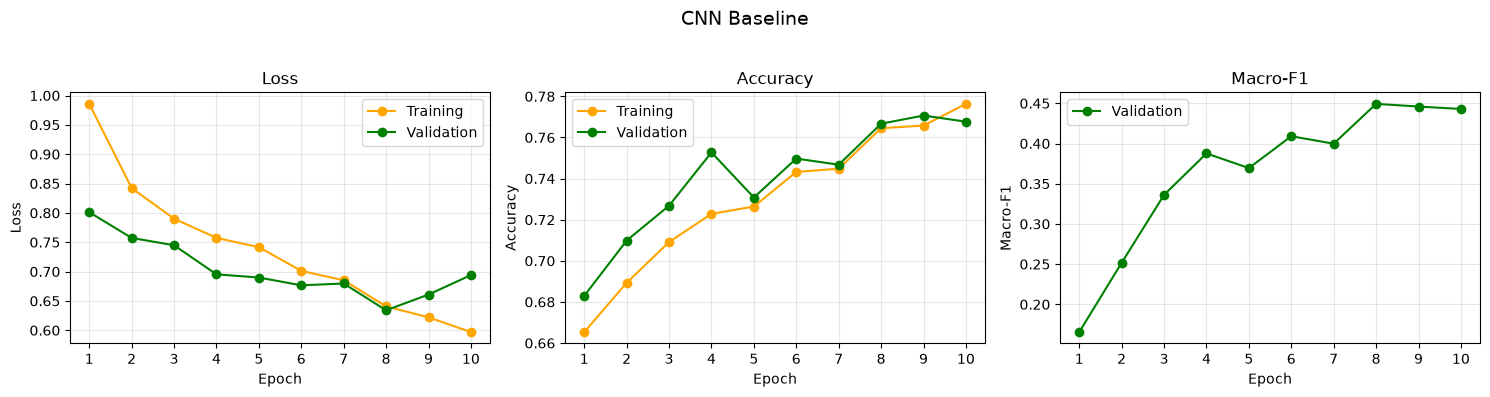

In [81]:
plot_learning_curves(history, title="CNN Baseline")

## Experiment 1: Class-Weighted Cross-Entropy

The baseline model showed a strong bias towards the biggest class. This experiment addresses the class imbalance by assigning larger loss weights to under-represented classes.

The CNN architecture, preprocessing, optimizer, learning rate, batch size, and training procedure remain unchanged. Only the loss function is modified.

The purpose of this experiment is to determine whether class weighting improves performance on minority classes and therefore increases validation macro-F1, while maintaining reasonable overall accuracy.

In [90]:
# calculate the weights using the balanced weighting scheme implemented in scikit-learn, 
# where each class receives a weight inversely proportional to its frequency
class_counts = np.array([228, 359, 769, 80, 779, 4693, 99])

num_samples = class_counts.sum()
num_classes = len(class_counts)

class_weights = num_samples / (num_classes * class_counts)

print("Class balanced weights:")
for class_id, weight in enumerate(class_weights):
    print(f"Class {class_id}: {weight:.4f}")

Class balanced weights:
Class 0: 4.3904
Class 1: 2.7883
Class 2: 1.3017
Class 3: 12.5125
Class 4: 1.2850
Class 5: 0.2133
Class 6: 10.1111


These weights will give greater importance to minority classes during loss calculation and reduce the relative contribution of the majority class. 

The weights are calculated using the training-set class frequencies only.

In [91]:
# convert the weights to a PyTorch tensor
class_weights = torch.tensor(class_weights, dtype=torch.float32)
print(class_weights)

tensor([ 4.3904,  2.7883,  1.3017, 12.5125,  1.2850,  0.2133, 10.1111])


#### Create new loss

We change the loss to use the balanced weights, and need a fresh model and optimizer before training.

In [92]:
model_1 = CNN(num_classes=7)
criterion_1 = nn.CrossEntropyLoss(weight=class_weights)
optimizer_1 = torch.optim.Adam(model_1.parameters(), lr=0.001)

In [93]:
# training loop for Experiment 1
history_1 = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_macro_f1": [],
    "epoch_time": []
}

start_time_1 = time.perf_counter()

for epoch in range(num_epochs):
    epoch_start = time.perf_counter()

    train_loss, train_accuracy = train_one_epoch(model_1, train_loader, criterion_1, optimizer_1)
    
    val_loss, val_accuracy, val_macro_f1 = evaluate(model_1, val_loader, criterion_1)

    epoch_time = time.perf_counter() - epoch_start

    history_1["train_loss"].append(train_loss)
    history_1["train_accuracy"].append(train_accuracy)
    history_1["val_loss"].append(val_loss)
    history_1["val_accuracy"].append(val_accuracy)
    history_1["val_macro_f1"].append(val_macro_f1)
    history_1["epoch_time"].append(epoch_time)

    print(
        f"Epoch {epoch + 1:2d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Val Macro-F1: {val_macro_f1:.4f} | "
        f"Time: {epoch_time:.2f}s")

training_time_1 = time.perf_counter() - start_time_1

print(f"\nExperiment 1 training time: {training_time_1:.2f}s")

Epoch  1/10 | Train Loss: 1.7734 | Train Acc: 0.3528 | Val Loss: 1.4681 | Val Acc: 0.5125 | Val Macro-F1: 0.2872 | Time: 27.37s
Epoch  2/10 | Train Loss: 1.5156 | Train Acc: 0.4774 | Val Loss: 1.4148 | Val Acc: 0.6401 | Val Macro-F1: 0.3556 | Time: 27.35s
Epoch  3/10 | Train Loss: 1.4279 | Train Acc: 0.4928 | Val Loss: 1.4048 | Val Acc: 0.5314 | Val Macro-F1: 0.3570 | Time: 27.57s
Epoch  4/10 | Train Loss: 1.3380 | Train Acc: 0.5263 | Val Loss: 1.2528 | Val Acc: 0.4736 | Val Macro-F1: 0.3511 | Time: 27.25s
Epoch  5/10 | Train Loss: 1.2936 | Train Acc: 0.5230 | Val Loss: 1.1962 | Val Acc: 0.5683 | Val Macro-F1: 0.4007 | Time: 27.37s
Epoch  6/10 | Train Loss: 1.2268 | Train Acc: 0.5420 | Val Loss: 1.1759 | Val Acc: 0.6012 | Val Macro-F1: 0.4087 | Time: 26.81s
Epoch  7/10 | Train Loss: 1.1939 | Train Acc: 0.5503 | Val Loss: 1.2752 | Val Acc: 0.5683 | Val Macro-F1: 0.3642 | Time: 26.56s
Epoch  8/10 | Train Loss: 1.1683 | Train Acc: 0.5504 | Val Loss: 1.1513 | Val Acc: 0.5823 | Val Macro-F1

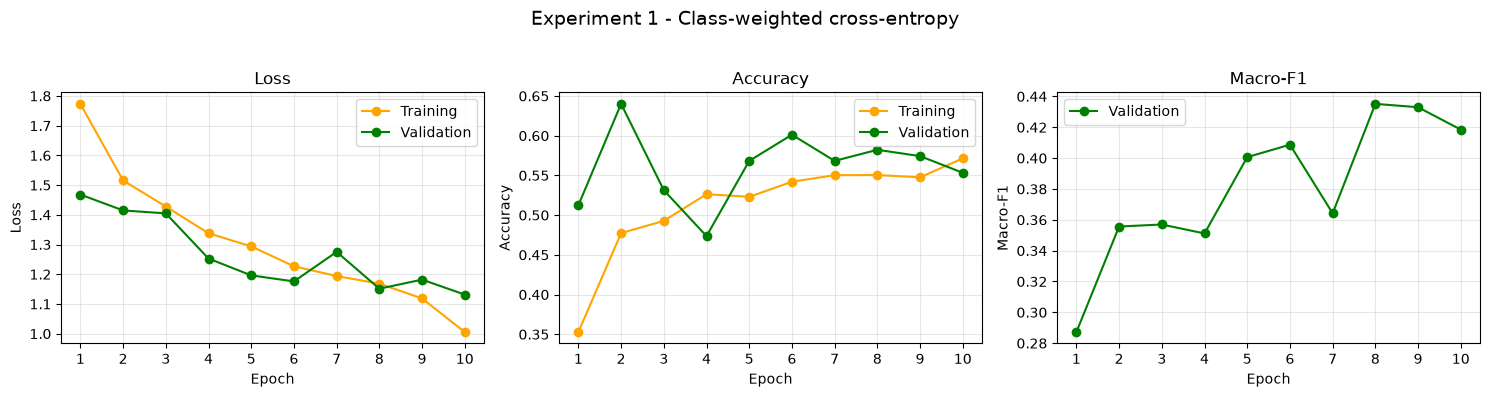

In [94]:
plot_learning_curves(history_1, title="Experiment 1 - Class-weighted cross-entropy")

Experiment 1 did not improve the overall accuracy, but interestingly, class-weighted model **didn't really improve macro-F1 either**. It did, however, substantially change the training behaviour: training accuracy is much lower because the model is being penalised much more heavily for errors on minority classes.

## Experiment 2: Controlled Oversampling and Data Augmentation

This experiment addresses the class imbalance by increasing the sampling frequency of under-represented classes during training.

We use a weighted random sampler to give minority classes a greater probability of being selected.

We also apply a mild random augmentation to the sampled training images using horizontal flipping and small rotations. This reduces the effect of repeatedly seeing the same minority-class images.

The validation and test sets remain unchanged. The CNN architecture, loss function, optimizer, learning rate, batch size, normalization, and number of epochs are kept consistent with the baseline.

In [95]:
# create the augmented training dataset
# we reuse the normalization statistics we already calculated

transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=mean.tolist(),
        std=std.tolist()
    )
])

train_dataset_aug = DermaMNIST(split="train", size=64, transform=transform_aug, download=False)